In [11]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy.io as sio

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

def get_velgradient(cg,pm,pn):
    u1=u2rho_3d(np.squeeze(cg['u'].values))
    v1=v2rho_3d(np.squeeze(cg['v'].values))
    ux=u2rho_3d((u1[:,:,1:]-u1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    vx=u2rho_3d((v1[:,:,1:]-v1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    uy=v2rho_3d((u1[:,1:,:]-u1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    vy=v2rho_3d((v1[:,1:,:]-v1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    return ux,vx,uy,vy

def get_traj(w):
    lon=w['lon'].values
    lat=w['lat'].values
    return lon,lat

import scipy.io as sio

def load_mat_as_namespace(file_path):
   
    class DataNamespace:
        pass
    
    data = sio.loadmat(file_path)
    ns = DataNamespace()
    
    for key, value in data.items():
        if not key.startswith('__'):
            setattr(ns, key, value)
    
    return ns
import xarray as xr
import re

def read_th_variables_numeric_sorted(fname):
  
    # 
    ds = xr.open_dataset(fname)
    th_vars = [var for var in ds.data_vars if var.startswith('th')]
    
    def extract_number(var_name):
        match = re.search(r'th(\d+)', var_name)
        if match:
            return int(match.group(1))
        return 0  
    
    th_vars_sorted = sorted(th_vars, key=extract_number)
    Th_arrays = [ds[var].values for var in th_vars_sorted]
    ds.close()
    
    return Th_arrays, th_vars_sorted

In [85]:
Casemean='Hf'
ini='_rough'
fignum=6
data_ns = load_mat_as_namespace(f'/meddy/simingzhang/Data/Figure_SF3/plot_Iceland_Bayesiankaiser_{ini}_{Casemean}.mat')
NN=10
data_ns.ymax_fk=4e-8

# load variables

In [86]:
fname = '/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T89.5days.nc'  
Th_arrays, var_names = read_th_variables_numeric_sorted(fname)
Th_289all=np.zeros((len(var_names),Th_arrays[0].shape[0],Th_arrays[0].shape[1]))
for i in range(len(var_names)):
    Th_289all[i,:,:]=Th_arrays[i]
Th_289all=Th_289all[1:,:,:] 
Th_289all_mn=np.nanmean(Th_289all,axis=(1,2))
Th_289all_std=np.nanstd(Th_289all,axis=(1,2))
# Th_289all_std2=np.nanstd(np.nanmean(Th_289all,axis=(2)),axis=1)

In [87]:
# data_ns.Fk_error289

In [88]:

colorsmap = ['#0072BD', '#D95319', '#EDB120', '#7E2F8E', '#77AC30', '#4DBEEE']
color_map = {
    'Hf': colorsmap[0],
    'Sm': colorsmap[1],
    'default': colorsmap[0]  # 默认颜色
}

color1 = color_map.get(Casemean, color_map['default'])

In [89]:
color1

'#0072BD'

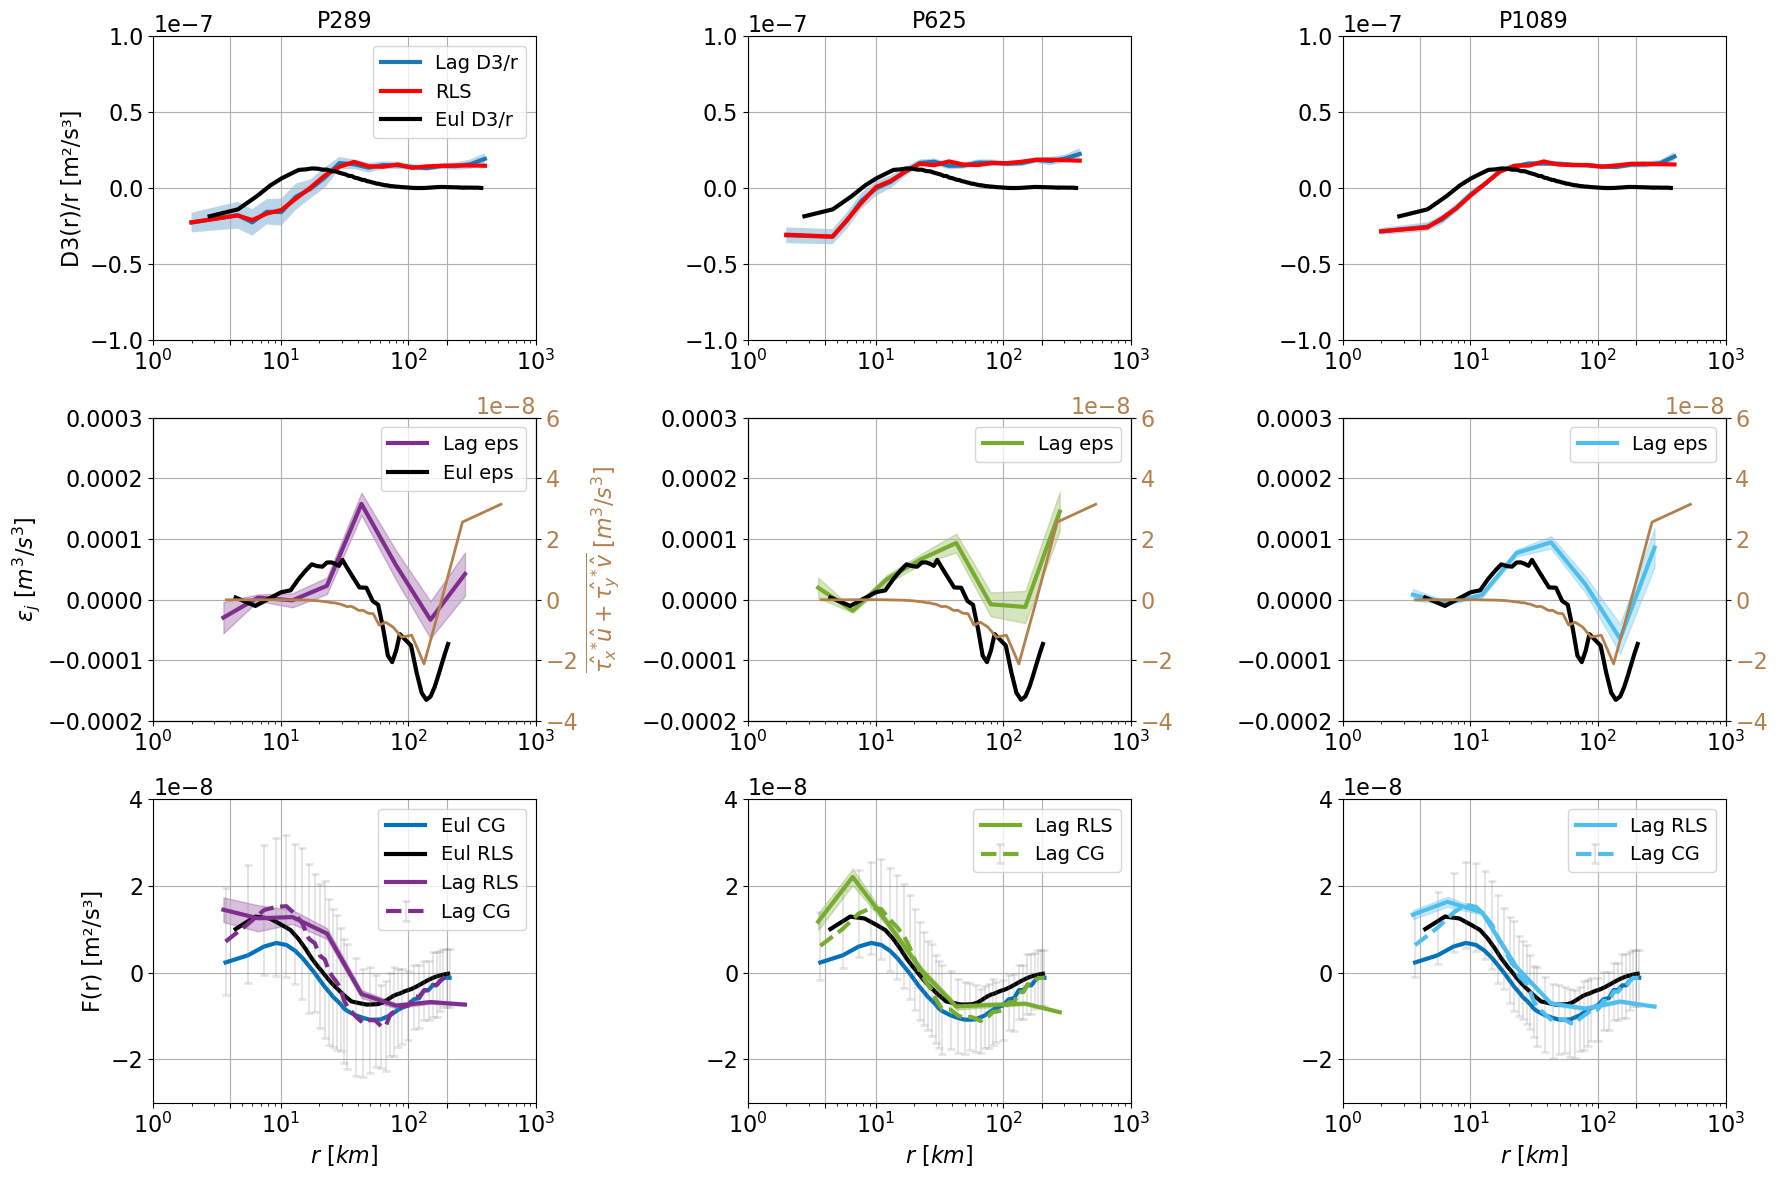

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 设置图形参数
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
})

# 创建3x3子图
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# 给每个子图分配变量名
# (ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9) = axes
(ax4, ax5, ax6), (ax7, ax8, ax9), (ax1, ax2, ax3) = axes

# 字母标签
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

# 

ax1.semilogx(data_ns.filtscale/1e3,data_ns.Thm_Eulerian, color=color1, linewidth=3, label='Eul CG')
ax1.semilogx((1/data_ns.kf_E/1e3*2*np.pi).T,data_ns.SpecFlux_E, color='k', linewidth=3, label='Eul RLS')
# ax1.semilogx(data_ns.filtscale/1e3,data_ns.Th_Lag289, color=colorsmap[3], linewidth=3, label='Lag CG',linestyle='--')
ax1.errorbar(np.squeeze(data_ns.filtscale/1e3), np.squeeze(data_ns.Th_Lag289),yerr=np.squeeze(data_ns.Th_Lag289_std),color=colorsmap[3],
             ecolor=(0.5, 0.5, 0.5, 0.2), linewidth=3, label='Lag CG', linestyle='--', capsize=3, capthick=2, elinewidth=1.5)
ax1.semilogx(1/data_ns.kf_Lag*2*np.pi/1e3,data_ns.SpecFlux_Lag289, color=colorsmap[3], linewidth=3, label='Lag RLS')
ax1.fill_between(np.squeeze(1/data_ns.kf_Lag*2*np.pi/1e3),np.squeeze(data_ns.SpecFlux_Lag289+(data_ns.Fk_error289)*NN), 
                 np.squeeze(data_ns.SpecFlux_Lag289-(data_ns.Fk_error289)*NN),color=colorsmap[3],alpha=0.3)

ax1.grid(True)
ax1.set_ylim([data_ns.ymin_fk, data_ns.ymax_fk])
ax1.set_xlim([data_ns.xmin, data_ns.xmax])
ax1.set_xticks([1, 4, 10, 100, 200, 1000])
# ax1.set_xlabel('r [km]')
ax1.set_ylabel('F(r) [m²/s³]')
ax1.legend()
# ax1.set_xticklabels('')
ax1.set_xlabel(r'$r \ [km]$')

ax2.semilogx(data_ns.filtscale/1e3,data_ns.Thm_Eulerian, color=color1, linewidth=3)
ax2.semilogx((1/data_ns.kf_E/1e3*2*np.pi).T,data_ns.SpecFlux_E, color='k', linewidth=3)
# ax2.semilogx(data_ns.filtscale/1e3,data_ns.Th_Lag625, color=colorsmap[4], linewidth=3, label='Lag CG',linestyle='--')
ax2.errorbar(np.squeeze(data_ns.filtscale/1e3), np.squeeze(data_ns.Th_Lag625),yerr=np.squeeze(data_ns.Th_Lag625_std),color=colorsmap[4],
             ecolor=(0.5, 0.5, 0.5, 0.2), linewidth=3, label='Lag CG', linestyle='--', capsize=3, capthick=2, elinewidth=1.5)
ax2.semilogx(1/data_ns.kf_Lag*2*np.pi/1e3,data_ns.SpecFlux_Lag625, color=colorsmap[4], linewidth=3, label='Lag RLS')
ax2.fill_between(np.squeeze(1/data_ns.kf_Lag*2*np.pi/1e3),np.squeeze(data_ns.SpecFlux_Lag625+(data_ns.Fk_error625)*NN), 
                 np.squeeze(data_ns.SpecFlux_Lag625-(data_ns.Fk_error625)*NN),color=colorsmap[4],alpha=0.3)
ax2.grid(True)
ax2.set_ylim([data_ns.ymin_fk, data_ns.ymax_fk])
ax2.set_xlim([data_ns.xmin, data_ns.xmax])
ax2.set_xticks([1, 4, 10, 100, 200, 1000])
# ax2.set_xlabel('r [km]')
# ax2.set_ylabel('F(r) [m²/s³]')
ax2.legend()
# ax2.set_xticklabels('')
# ax2.set_yticklabels('')
ax2.set_xlabel(r'$r \ [km]$')


ax3.semilogx(data_ns.filtscale/1e3,data_ns.Thm_Eulerian, color=color1, linewidth=3)
ax3.semilogx((1/data_ns.kf_E/1e3*2*np.pi).T,data_ns.SpecFlux_E, color='k', linewidth=3)
# ax3.semilogx(data_ns.filtscale/1e3,data_ns.Th_Lag1089, color=colorsmap[5], linewidth=3, label='Lag CG',linestyle='--')
ax3.errorbar(np.squeeze(data_ns.filtscale/1e3), np.squeeze(data_ns.Th_Lag1089),yerr=np.squeeze(data_ns.Th_Lag1089_std),color=colorsmap[5],
             ecolor=(0.5, 0.5, 0.5, 0.2), linewidth=3, label='Lag CG', linestyle='--', capsize=3, capthick=2, elinewidth=1.5)
ax3.semilogx(1/data_ns.kf_Lag*2*np.pi/1e3,data_ns.SpecFlux_Lag1089, color=colorsmap[5], linewidth=3, label='Lag RLS')
ax3.fill_between(np.squeeze(1/data_ns.kf_Lag*2*np.pi/1e3),np.squeeze(data_ns.SpecFlux_Lag1089+(data_ns.Fk_error1089)*NN), 
                 np.squeeze(data_ns.SpecFlux_Lag1089-(data_ns.Fk_error1089)*NN),color=colorsmap[5],alpha=0.3)
ax3.grid(True)
ax3.set_ylim([data_ns.ymin_fk, data_ns.ymax_fk])
ax3.set_xlim([data_ns.xmin, data_ns.xmax])
ax3.set_xticks([1, 4, 10, 100, 200, 1000])
# ax3.set_xlabel('r [km]')
# ax3.set_ylabel('F(r) [m²/s³]')
ax3.legend()
# ax3.set_xticklabels('')
# ax3.set_yticklabels('')
ax3.set_xlabel(r'$r \ [km]$')


ax4.semilogx(data_ns.dist_axis/1e3,data_ns.SF3_Lag289/data_ns.dist_axis, linewidth=3, label='Lag D3/r')
ax4.fill_between(np.squeeze(data_ns.dist_axis/1e3),np.squeeze((data_ns.SF3_Lag289+data_ns.SF3_Lag289_std)/data_ns.dist_axis),
                np.squeeze((data_ns.SF3_Lag289-data_ns.SF3_Lag289_std)/data_ns.dist_axis),alpha=0.3)
ax4.semilogx(data_ns.dist_axis/1e3,data_ns.Vt_Lag289/data_ns.dist_axis, linewidth=3,color='r',label='RLS')
ax4.semilogx(data_ns.r_E/1e3,data_ns.SF3_E/data_ns.r_E, linewidth=3, label='Eul D3/r',color='k')
ax4.set_xlim([data_ns.xmin, data_ns.xmax])
ax4.set_ylim([data_ns.ymin_sf, data_ns.ymax_sf])
# 
ax4.set_xticks([1, 4, 10, 100, 200, 1000])
ax4.grid(True)
ax4.legend()
ax4.set_ylabel('D3(r)/r [m²/s³]')
ax4.set_title('P289')

# ax4.set_xticklabels('')

ax5.semilogx(data_ns.dist_axis/1e3,data_ns.SF3_Lag625/data_ns.dist_axis, linewidth=3)
ax5.fill_between(np.squeeze(data_ns.dist_axis/1e3),np.squeeze((data_ns.SF3_Lag625+data_ns.SF3_Lag625_std)/data_ns.dist_axis),
                np.squeeze((data_ns.SF3_Lag625-data_ns.SF3_Lag625_std)/data_ns.dist_axis),alpha=0.3)
ax5.semilogx(data_ns.dist_axis/1e3,data_ns.Vt_Lag625/data_ns.dist_axis, linewidth=3,color='r',label='RLS')
ax5.semilogx(data_ns.r_E/1e3,data_ns.SF3_E/data_ns.r_E, linewidth=3,color='k')
ax5.set_xlim([data_ns.xmin, data_ns.xmax])
ax5.set_ylim([data_ns.ymin_sf, data_ns.ymax_sf])
# 
ax5.set_xticks([1, 4, 10, 100, 200, 1000])
ax5.grid(True)
ax5.set_title('P625')

# ax5.set_xticklabels('')
# ax5.set_yticklabels('')

ax6.semilogx(data_ns.dist_axis/1e3,data_ns.SF3_Lag1089/data_ns.dist_axis, linewidth=3)
ax6.fill_between(np.squeeze(data_ns.dist_axis/1e3),np.squeeze((data_ns.SF3_Lag1089+data_ns.SF3_Lag1089_std)/data_ns.dist_axis),
                np.squeeze((data_ns.SF3_Lag1089-data_ns.SF3_Lag1089_std)/data_ns.dist_axis),alpha=0.3)
ax6.semilogx(data_ns.dist_axis/1e3,data_ns.Vt_Lag1089/data_ns.dist_axis, linewidth=3,color='r',label='RLS')
ax6.semilogx(data_ns.r_E/1e3,data_ns.SF3_E/data_ns.r_E, linewidth=3,color='k')
ax6.set_xlim([data_ns.xmin, data_ns.xmax])
ax6.set_ylim([data_ns.ymin_sf, data_ns.ymax_sf])
# 
ax6.set_xticks([1, 4, 10, 100, 200, 1000])
ax6.grid(True)
ax6.set_title('P1089')

# ax6.set_xticklabels('')
# ax6.set_yticklabels('')

# ax7.semilogx(1/data_ns.kf_Lag/1e3*2*np.pi,data_ns.eps_Lag289[1:], linewidth=3, label='Lag eps',color=colorsmap[3])
# ax7.fill_between(np.squeeze(1/data_ns.kf_Lag/1e3*2*np.pi),np.squeeze(data_ns.eps_Lag289[1:]+data_ns.eps_error289[1:]),
#                 np.squeeze(data_ns.eps_Lag289[1:]-data_ns.eps_error289[1:]),alpha=0.3,color=colorsmap[3])

# ax7.set_xticks([1, 4, 10, 100, 200, 1000])
# ax7.grid(True)
# ax7.legend()

# ax7.set_ylim([data_ns.ymin_ebsdk, data_ns.ymax_ebsdk])
# ax7.set_xlim([0.5e3/1e3, 1e6/1e3]) 

# ax7.set_xlabel(r'$r \ [km]$')
# ax7.set_ylabel(r'$\epsilon_j  \ [m^{3}/s^{3}]$')

line_left = ax7.semilogx(1/data_ns.kf_Lag/1e3 * 2*np.pi, data_ns.eps_Lag289[1:], 
                         linewidth=3, label='Lag eps', color=colorsmap[3])
line_left2 = ax7.semilogx(np.squeeze(1/data_ns.kf_E/1e3 * 2*np.pi), np.squeeze(data_ns.ebs_E[:-1]), 
                         linewidth=3, label='Eul eps', color='k')
ax7.set_xlim([data_ns.xmin, data_ns.xmax])
# 添加误差带
fill_left = ax7.fill_between(np.squeeze(1/data_ns.kf_Lag/1e3 * 2*np.pi),
                             np.squeeze(data_ns.eps_Lag289[1:]+data_ns.eps_error289[1:]*NN),
                             np.squeeze(data_ns.eps_Lag289[1:]-data_ns.eps_error289[1:]*NN),
                             alpha=0.3, color=colorsmap[3])

# 设置左侧y轴属性
ax7.set_xticks([1, 4, 10, 100, 200, 1000])
ax7.grid(True)
ax7.set_ylim([data_ns.ymin_ebsdk, data_ns.ymax_ebsdk])


ax7.set_ylabel(r'$\epsilon_j \ [m^{3}/s^{3}]$')
ax7.tick_params(axis='y', labelcolor='k')

# 
ax7_right = ax7.twinx()

line_right = ax7_right.semilogx(np.squeeze(1/data_ns.K1D/1e3), np.squeeze(data_ns.ww_mean),  # 替换为您的数据
                                linewidth=2, label='Wind work', 
                                color=[0.7, 0.5, 0.3], linestyle='-')

ax7_right.set_ylabel(r'$\overline{\hat{\tau_{x}}^{*}\hat{u}+\hat{\tau_{y}}^{*}\hat{v}} \ [m^{3}/s^{3}]$', color=[0.7, 0.5, 0.3])
ax7_right.tick_params(axis='y', labelcolor=[0.7, 0.5, 0.3])
ax7_right.set_ylim([data_ns.ymin_right, data_ns.ymax_right])  # 设

lines_left, labels_left = ax7.get_legend_handles_labels()
lines_right, labels_right = ax7_right.get_legend_handles_labels()
ax7_right.set_xlim([data_ns.xmin, data_ns.xmax])

# ax7.legend(lines_left + lines_right, labels_left + labels_right, 
#            loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax7.legend()


line_left = ax8.semilogx(1/data_ns.kf_Lag/1e3 * 2*np.pi, data_ns.eps_Lag625[1:], 
                         linewidth=3, label='Lag eps', color=colorsmap[4])
line_left2 = ax8.semilogx(np.squeeze(1/data_ns.kf_E/1e3 * 2*np.pi), np.squeeze(data_ns.ebs_E[:-1]), 
                         linewidth=3,  color='k')

fill_left = ax8.fill_between(np.squeeze(1/data_ns.kf_Lag/1e3 * 2*np.pi),
                             np.squeeze(data_ns.eps_Lag625[1:]+data_ns.eps_error625[1:]*NN),
                             np.squeeze(data_ns.eps_Lag625[1:]-data_ns.eps_error625[1:]*NN),
                             alpha=0.3, color=colorsmap[4])
ax8.set_xticks([1, 4, 10, 100, 200, 1000])
ax8.grid(True)
ax8.set_ylim([data_ns.ymin_ebsdk, data_ns.ymax_ebsdk])
ax8.tick_params(axis='y', labelcolor='k')
ax8.set_xlim([data_ns.xmin, data_ns.xmax])

# 
ax8_right = ax8.twinx()
line_right = ax8_right.semilogx(np.squeeze(1/data_ns.K1D/1e3), np.squeeze(data_ns.ww_mean),  # 替换为您的数据
                                linewidth=2, 
                                color=[0.7, 0.5, 0.3], linestyle='-')
ax8_right.tick_params(axis='y', labelcolor=[0.7, 0.5, 0.3])
ax8_right.set_ylim([data_ns.ymin_right, data_ns.ymax_right])  # 设

lines_left, labels_left = ax8.get_legend_handles_labels()
lines_right, labels_right = ax8_right.get_legend_handles_labels()
# ax7.legend(lines_left + lines_right, labels_left + labels_right, 
#            loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax8.legend()
# ax8.set_yticklabels('')
# ax8_right.set_yticklabels('')
ax8_right.set_xlim([data_ns.xmin, data_ns.xmax])


line_left = ax9.semilogx(1/data_ns.kf_Lag/1e3 * 2*np.pi, data_ns.eps_Lag1089[1:], 
                         linewidth=3, label='Lag eps', color=colorsmap[5])
line_left2 = ax9.semilogx(np.squeeze(1/data_ns.kf_E/1e3 * 2*np.pi), np.squeeze(data_ns.ebs_E[:-1]), 
                         linewidth=3,  color='k')

fill_left = ax9.fill_between(np.squeeze(1/data_ns.kf_Lag/1e3 * 2*np.pi),
                             np.squeeze(data_ns.eps_Lag1089[1:]+data_ns.eps_error1089[1:]*NN),
                             np.squeeze(data_ns.eps_Lag1089[1:]-data_ns.eps_error1089[1:]*NN),
                             alpha=0.3, color=colorsmap[5])
ax9.set_xticks([1, 4, 10, 100, 200, 1000])
ax9.grid(True)
ax9.set_ylim([data_ns.ymin_ebsdk, data_ns.ymax_ebsdk])
ax9.tick_params(axis='y', labelcolor='k')
ax9.set_xlim([data_ns.xmin, data_ns.xmax])

# 
ax9_right = ax9.twinx()
line_right = ax9_right.semilogx(np.squeeze(1/data_ns.K1D/1e3), np.squeeze(data_ns.ww_mean),  # 替换为您的数据
                                linewidth=2, 
                                color=[0.7, 0.5, 0.3], linestyle='-')
ax9_right.tick_params(axis='y', labelcolor=[0.7, 0.5, 0.3])
ax9_right.set_ylim([data_ns.ymin_right, data_ns.ymax_right])  # 设

lines_left, labels_left = ax9.get_legend_handles_labels()
lines_right, labels_right = ax9_right.get_legend_handles_labels()
# ax7.legend(lines_left + lines_right, labels_left + labels_right, 
#            loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax9.legend()
# ax9.set_yticklabels('')
# ax9_right.set_yticklabels('')
ax9_right.set_xlim([data_ns.xmin, data_ns.xmax])


plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig{fignum}_Iceland_{Casemean}{ini}_fk_eps_fitting_3x3.png', dpi=300, bbox_inches='tight')

# 显示图形
plt.show()

In [65]:
np.squeeze(data_ns.Th_Lag289_std)

array([8.83415461e-09, 1.01001948e-08, 1.16151504e-08, 1.32490977e-08,
       1.44477796e-08, 1.50659759e-08, 1.58280097e-08, 1.66345015e-08,
       1.49399976e-08, 1.42850121e-08, 1.63227825e-08, 1.46819187e-08,
       1.52090314e-08, 1.39696255e-08, 1.56833842e-08, 1.41298921e-08,
       1.44733917e-08, 1.73791317e-08, 1.28963770e-08, 1.21165714e-08,
       1.27052065e-08, 1.12185767e-08, 1.22079741e-08, 1.05454674e-08,
       1.00085879e-08, 9.05907845e-09, 7.01031962e-09, 8.26560723e-09,
       7.41530287e-09, 6.15910329e-09, 5.48393731e-09, 5.48393731e-09,
       5.56689055e-09, 5.56689055e-09, 4.22914602e-09, 4.03225233e-09,
       4.03225233e-09, 4.03225233e-09])

<ErrorbarContainer object of 3 artists>

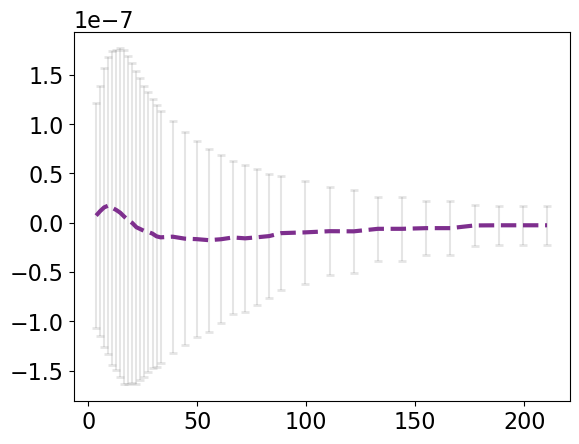

In [66]:
plt.errorbar(np.squeeze(data_ns.filtscale/1e3), np.squeeze(data_ns.Th_Lag289),yerr=Th_289all_std,color=colorsmap[3],
             ecolor=(0.5, 0.5, 0.5, 0.2), linewidth=3, label='Lag CG', linestyle='--', capsize=3, capthick=2, elinewidth=1.5)

In [72]:
data_ns.filtscale.shape

(38, 1)

Text(0.5, 1.0, 'P289: CG with temporal-spatial std and RLS fitting with uncertainty shading')

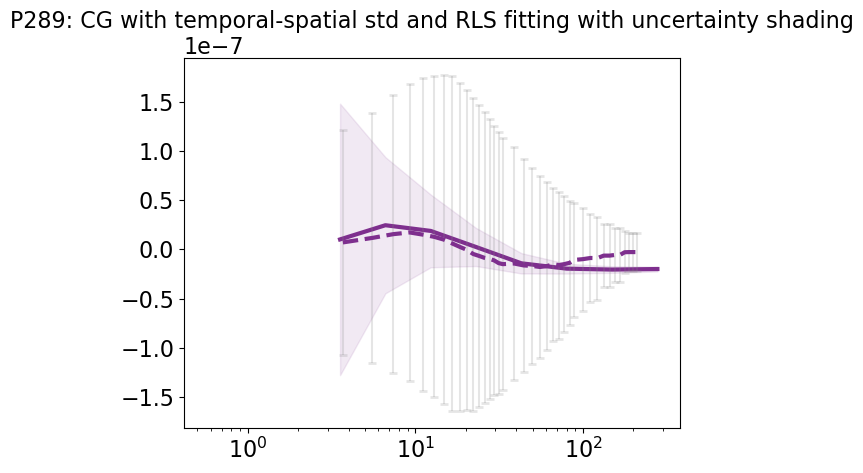

In [104]:
plt.semilogx(1/data_ns.kf_Lag*2*np.pi/1e3,data_ns.SpecFlux_Lag289, color=colorsmap[3], linewidth=3, label='Lag RLS')
plt.fill_between(np.squeeze(1/data_ns.kf_Lag*2*np.pi/1e3),np.squeeze(data_ns.SpecFlux_Lag289+(data_ns.Fk_error289)), 
                 np.squeeze(data_ns.SpecFlux_Lag289-(data_ns.Fk_error289)),color=colorsmap[3],alpha=0.3)
plt.errorbar(np.squeeze(data_ns.filtscale/1e3), np.squeeze(data_ns.Th_Lag289),yerr=Th_289all_std,color=colorsmap[3],
             ecolor=(0.5, 0.5, 0.5, 0.2), linewidth=3, label='Lag CG', linestyle='--', capsize=3, capthick=2, elinewidth=1.5)
plt.title('P289: CG with temporal-spatial std and RLS fitting with uncertainty shading')